In [1]:
import os
from pathlib import Path
import math

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd
from IPython.display import Image, display

def _pdf_subsettable(path):
    """The bundled Helvetica.ttf has a corrupt 'glyf' table that renders fine as
    PNG but crashes PDF Type-42 embedding (fontTools subsetting). Validate before use."""
    try:
        from fontTools.ttLib import TTFont
        from fontTools.subset import Subsetter, Options
        f = TTFont(path)
        ss = Subsetter(options=Options())
        ss.populate(text='ABCabc0123 .%/')
        ss.subset(f)
        return True
    except Exception:
        return False


# Prefer the bundled Helvetica; fall back to Nimbus Sans (a valid Helvetica clone)
# when the bundled regular face is broken for PDF embedding.
_font_candidates = [
    'figutils/Helvetica.ttf',
    '/usr/share/fonts/opentype/urw-base35/NimbusSans-Regular.otf',
]
_bold_candidates = [
    'figutils/Helvetica Bold.ttf',
    '/usr/share/fonts/opentype/urw-base35/NimbusSans-Bold.otf',
]

FONT_FAMILY = 'DejaVu Sans'  # final fallback
for cand in _font_candidates:
    if os.path.exists(cand) and _pdf_subsettable(cand):
        fm.fontManager.addfont(cand)
        FONT_FAMILY = fm.FontProperties(fname=cand).get_name()
        # register a matching bold face from the same family if available
        for bold in _bold_candidates:
            if os.path.exists(bold) and fm.FontProperties(fname=bold).get_name() == FONT_FAMILY:
                if _pdf_subsettable(bold):
                    fm.fontManager.addfont(bold)
                break
        plt.rcParams['font.family'] = FONT_FAMILY
        break

print(FONT_FAMILY)

ROOT = Path('/home/hsh/hsh/GPT-Disease-Drug-Prediction')
ATTN_DIR = ROOT / 'results/0506/xai_attention_kr_val_n500_20260707/report_no_static_anchor'
OUT_DIR = ROOT / 'figure/out'
OUT_DIR.mkdir(parents=True, exist_ok=True)

ENRICHMENT_CSV = ATTN_DIR / 'attention_enrichment/attention_enrichment_summary.csv'
PATIENT_VALUES_CSV = ATTN_DIR / 'attention_enrichment/attention_enrichment_patient_values.csv'
TOKEN_CSV = ATTN_DIR / 'attention_enrichment/attention_token_enrichment_summary.csv'
RUN_SUMMARY_CSV = ROOT / 'results/0506/xai_attention_kr_val_n500_20260707/attention/attention_selected_events.csv'

OUT_PREFIX = 'attention_tokens'
PNG_PATH = OUT_DIR / f'{OUT_PREFIX}.png'
PDF_PATH = OUT_DIR / f'{OUT_PREFIX}.pdf'
TOKEN_VALUES_PATH = OUT_DIR / f'{OUT_PREFIX}.csv'

TARGET_ORDER = ['I21', 'I50', 'N18', 'Death', 'Insulin_start']
TARGET_LABELS = {
    'I21': 'I21 Acute Myocardial infarction',
    'I50': 'I50 Heart failure',
    'N18': 'N18 Chronic kidney disease',
    'Death': 'Death',
    'Insulin_start': 'Insulin initiation',
}

# CATEGORY_LABELS = {
#     'ICD: I. Infectious Diseases': 'Infectious dx',
#     'ICD: II. Neoplasms': 'Neoplasms',
#     'ICD: III. Blood & Immune Disorders': 'Blood/immune dx',
#     'ICD: IV. Metabolic Diseases': 'Metabolic dx',
#     'ICD: V. Mental Disorders': 'Mental dx',
#     'ICD: VI. Nervous System Diseases': 'Nervous dx',
#     'ICD: VII. Eye Diseases': 'Eye dx',
#     'ICD: VIII. Ear Diseases': 'Ear dx',
#     'ICD: IX. Circulatory Diseases': 'Circulatory dx',
#     'ICD: X. Respiratory Diseases': 'Respiratory dx',
#     'ICD: XI. Digestive Diseases': 'Digestive dx',
#     'ICD: XII. Skin Diseases': 'Skin dx',
#     'ICD: XIII. Musculoskeletal Diseases': 'Musculoskeletal dx',
#     'ICD: XIV. Genitourinary Diseases': 'Genitourinary dx',
#     'ICD: XV. Pregnancy & Childbirth': 'Pregnancy dx',
#     'Drug: Alpha-glucosidase inhibitors': 'Alpha-glucosidase inhibitor',
#     'Drug: DPP-4 inhibitor': 'DPP-4 inhibitor',
#     'Drug: GLP-1': 'GLP-1',
#     'Drug: Insulin': 'Insulin',
#     'Drug: Meglitinide': 'Meglitinide',
#     'Drug: Metformin': 'Metformin',
#     'Drug: SGLT-2 inhibitor': 'SGLT-2 inhibitor',
#     'Drug: Sulfonylurea': 'Sulfonylurea',
#     'Drug: Thiazolidinedione': 'Thiazolidinedione',
#     'Death': 'Death token',
# }

COLORS = {
    'diagnosis': '#4C78A8',
    'drug': '#F58518',
    'death': '#4D4D4D',
}

# --- ICD chapter colour palette (shared with figure/auc_scatter.ipynb) ---
# Same remapping auc_scatter/umap use to soften the raw tab20 colours.
COLOR_REMAP = {
    '#98df8a': '#91c987',  # I. Infectious Diseases
    '#ff7f0e': '#ec713f',  # II. Neoplasms
    '#ff9896': '#dd5752',  # III. Blood & Immune Disorders
    '#2ca02c': '#4f7951',  # IV. Metabolic Diseases
    '#9edae5': '#90c0c2',  # V. Mental Disorders
    '#7f7f7f': '#87776a',  # VI. Nervous System Diseases
    '#dbdb8d': '#e6c186',  # VIII. Ear Diseases
    '#d62728': '#c34a54',  # IX. Circulatory Diseases
    '#17becf': '#567797',  # X. Respiratory Diseases
    '#8c564b': '#6b512a',  # XI. Digestive Diseases
    '#1f77b4': '#2964b8',  # XIII. Musculoskeletal Diseases
    '#ffbb78': '#f7b141',  # XIV. Genitourinary Diseases
    '#e377c2': '#e45c88',  # XV. Pregnancy & Childbirth
    '#FFFF00': '#E7C547',  # XX. Diabetes drugs
    '#000a35': '#1d1f20',  # Death
}

_LABELS_CANDIDATES = [
    ROOT.parent / 'data' / 'labels_chapter.csv',
    ROOT / 'data' / 'labels_chapter.csv',
]
_LABELS_PATH = next((p for p in _LABELS_CANDIDATES if p.exists()), None)

# chapter_short (e.g. 'IX. Circulatory Diseases') -> hex colour
CHAPTER_COLORS: dict[str, str] = {}
DRUG_COLOR = '#E7C547'   # diabetes-drug colour from the chapter palette
DEATH_COLOR = '#1d1f20'
if _LABELS_PATH is not None:
    _labels = pd.read_csv(_LABELS_PATH)
    _labels.columns = ['name', 'token_id', 'chapter_full', 'chapter_short', 'color']
    _labels['color'] = _labels['color'].replace(COLOR_REMAP)
    CHAPTER_COLORS = (
        _labels[['chapter_short', 'color']]
        .drop_duplicates('chapter_short')
        .set_index('chapter_short')['color']
        .to_dict()
    )
    DRUG_COLOR = _labels.loc[_labels['chapter_short'].eq('XX. Diabetes drugs'), 'color'].iloc[0] \
        if (_labels['chapter_short'].eq('XX. Diabetes drugs')).any() else DRUG_COLOR
    DEATH_COLOR = CHAPTER_COLORS.get('Death', DEATH_COLOR)


def color_for_category(category: str) -> str:
    """Colour a bar by its ICD chapter; drugs and death use their palette colours."""
    if category == 'Death':
        return DEATH_COLOR
    if category.startswith('Drug:'):
        return DRUG_COLOR
    if category.startswith('ICD:'):
        short = category[len('ICD:'):].strip()
        return CHAPTER_COLORS.get(short, COLORS['diagnosis'])
    return COLORS['diagnosis']


def darken(color, factor: float = 0.75) -> tuple:
    """Return a darker shade of a colour (factor<1 = darker) for bar edges."""
    import matplotlib.colors as mcolors
    r, g, b = mcolors.to_rgb(color)
    return (r * factor, g * factor, b * factor)


import re as _re
from matplotlib.offsetbox import TextArea, HPacker, AnnotationBbox


def split_code_name(label: str):
    """Split an 'I21 Acute myocardial infarction' style label into (code, name).

    Returns ('', label) when there is no leading ICD-10 code (e.g. 'Death')."""
    m = _re.match(r'^([A-Z]\d[A-Za-z0-9.]*)\s+(.*)$', label)
    if m:
        return m.group(1), m.group(2)
    return '', label


def set_split_title(ax, label: str, fontsize: float = 10, y: float = 1.02):
    """Left-aligned panel title with the ICD-10 code in bold and the name in regular weight."""
    code, name = split_code_name(label)
    children = []
    if code:
        children.append(TextArea(code, textprops=dict(fontweight='bold', fontsize=fontsize)))
        children.append(TextArea(' ' + name, textprops=dict(fontweight='normal', fontsize=fontsize)))
    else:
        # No ICD-10 code (e.g. 'Death', 'Insulin initiation'): render the whole title bold.
        children.append(TextArea(name, textprops=dict(fontweight='bold', fontsize=fontsize)))
    box = HPacker(children=children, align='baseline', pad=0, sep=0)
    ab = AnnotationBbox(
        box, (0.0, y), xycoords='axes fraction',
        box_alignment=(0.0, 0.0), frameon=False, pad=0.0, annotation_clip=False,
    )
    ax.add_artist(ab)


def set_split_yticklabels(ax, positions, labels, fontsize: float = 9, pad: float = 0.012):
    """Right-aligned y-tick labels with the ICD-10 code in bold and the name in regular weight."""
    ax.set_yticks(positions)
    ax.set_yticklabels([])
    trans = ax.get_yaxis_transform()  # x in axes fraction, y in data coords
    for yi, label in zip(positions, labels):
        code, name = split_code_name(label)
        children = []
        if code:
            children.append(TextArea(code, textprops=dict(fontweight='bold', fontsize=fontsize)))
            children.append(TextArea(' ' + name, textprops=dict(fontweight='normal', fontsize=fontsize)))
        else:
            children.append(TextArea(name, textprops=dict(fontweight='normal', fontsize=fontsize)))
        box = HPacker(children=children, align='baseline', pad=0, sep=0)
        ab = AnnotationBbox(
            box, (-pad, yi), xycoords=trans,
            box_alignment=(1.0, 0.5), frameon=False, pad=0.0, annotation_clip=False,
        )
        ax.add_artist(ab)


CIRCULATORY_COLOR = CHAPTER_COLORS.get('IX. Circulatory Diseases', '#c34a54')

# Roman-numeral order for the chapter legend (drugs/death appended separately).
ICD_CHAPTER_SHORT_ORDER = [
    'I. Infectious Diseases',
    'II. Neoplasms',
    'III. Blood & Immune Disorders',
    'IV. Metabolic Diseases',
    'V. Mental Disorders',
    'VI. Nervous System Diseases',
    'VII. Eye Diseases',
    'VIII. Ear Diseases',
    'IX. Circulatory Diseases',
    'X. Respiratory Diseases',
    'XI. Digestive Diseases',
    'XII. Skin Diseases',
    'XIII. Musculoskeletal Diseases',
    'XIV. Genitourinary Diseases',
    'XV. Pregnancy & Childbirth',
    'XVI. Perinatal Conditions',
    'XVII. Congenital Abnormalities',
]

TOP_ATTENTION_CATEGORIES = 8
MIN_SUPPORT_PATIENTS = 20
MIN_MAIN_ATTENTION_SHARE = 0.01
MAX_EXTRA_ENRICHED_CATEGORIES = 1

I21_CIRCULATORY_TOKEN_IDS = [
    508,  # I10 Essential primary hypertension
    513,  # I20 Angina pectoris
    518,  # I25 Chronic ischaemic heart disease
    509,  # I11 Hypertensive heart disease
    548,  # I63 Cerebral infarction
    552,  # I67 Other cerebrovascular diseases
    542,  # I50 Heart failure
    541,  # I49 Other cardiac arrhythmias
]

TOKEN_LABELS = {
    508: 'I10 Essential primary hypertension',
    513: 'I20 Angina pectoris',
    518: 'I25 Chronic ischaemic heart disease',
    509: 'I11 Hypertensive heart disease',
    548: 'I63 Cerebral infarction',
    552: 'I67 Other cerebrovascular diseases',
    542: 'I50 Heart failure',
    541: 'I49 Other cardiac arrhythmias',
}


def category_type(category: str) -> str:
    if category.startswith('Drug:'):
        return 'drug'
    if category == 'Death':
        return 'death'
    return 'diagnosis'


# def short_label(category: str) -> str:
#     return CATEGORY_LABELS.get(category, category.replace('ICD: ', '').replace('Drug: ', ''))


def ci95(values: pd.Series) -> float:
    n = values.notna().sum()
    if n <= 1:
        return 0.0
    return 1.96 * values.std(ddof=1) / math.sqrt(n)


def select_categories(target_df: pd.DataFrame) -> list[str]:
    top_attention = (
        target_df.sort_values('mean_attention_share', ascending=False)
        .head(TOP_ATTENTION_CATEGORIES)['category']
        .tolist()
    )
    eligible_enriched = target_df[
        target_df['enrichment_ratio'].replace([np.inf, -np.inf], np.nan).notna()
        & (target_df['patients_with_category'] >= MIN_SUPPORT_PATIENTS)
        & (target_df['mean_attention_share'] >= MIN_MAIN_ATTENTION_SHARE)
    ]
    top_enriched = (
        eligible_enriched.sort_values('enrichment_ratio', ascending=False)
        .head(MAX_EXTRA_ENRICHED_CATEGORIES)['category']
        .tolist()
    )
    selected = []
    for category in top_attention + top_enriched:
        if category not in selected and category != 'Death':
            selected.append(category)
    return selected

Nimbus Sans


## Figure generation code

In [2]:
def generate_figure() -> pd.DataFrame:
    mpl.rcParams.update(
        {
            'font.family': FONT_FAMILY,
            'font.size': 9,
            'axes.titlesize': 10,
            'axes.labelsize': 9,
            'xtick.labelsize': 8,
            'ytick.labelsize': 8,
            'legend.fontsize': 8,
            'pdf.fonttype': 42,
            'ps.fonttype': 42,
        }
    )

    summary = pd.read_csv(ENRICHMENT_CSV)
    patient = pd.read_csv(PATIENT_VALUES_CSV)
    selected_events = pd.read_csv(RUN_SUMMARY_CSV)
    token = pd.read_csv(TOKEN_CSV)
    n_by_target = selected_events.groupby('target').size().to_dict()

    attention_ci = (
        patient.groupby(['target', 'category'], as_index=False)['attention_share_included']
        .agg(mean_attention_share_check='mean', attention_ci95=ci95)
    )
    summary = summary.merge(attention_ci, on=['target', 'category'], how='left')

    target_rows = [('category', target) for target in TARGET_ORDER]

    fig = plt.figure(figsize=(10, 11), constrained_layout=False)
    gs = fig.add_gridspec(
        nrows=len(target_rows),
        ncols=2,
        width_ratios=[1, 1],
        height_ratios=[1.0] * len(target_rows),
        hspace=0.38,
        wspace=0.08,
    )

    # fig.suptitle(
    #     'Attention over pre-event clinical history',
    #     x=0.02,
    #     y=0.994,
    #     ha='left',
    #     va='top',
    #     fontsize=16,
    #     fontweight='bold',
    # )
    # fig.text(
    #     0.02,
    #     0.968,
    #     'Full-attention layers 3/5/7 averaged across heads; query token, sex, and lifestyle/vitals excluded.',
    #     ha='left',
    #     va='top',
    #     fontsize=9,
    #     color='#4D4D4D',
    # )

    selected_by_target: dict[str, list[str]] = {}
    max_attention = 0.0
    for target in TARGET_ORDER:
        tdf = summary[summary['target'].eq(target)].copy()
        cats = select_categories(tdf)
        selected_by_target[target] = cats
        max_attention = max(
            max_attention,
            tdf[tdf['category'].isin(cats)]['mean_attention_share'].max(),
        )
    attention_xlim = max(math.ceil(max_attention * 100 / 5) * 5, 20)

    token_df = token[
        token['target'].eq('I21')
        & token['token_id'].isin(I21_CIRCULATORY_TOKEN_IDS)
    ].copy()
    token_df['display_label'] = token_df['token_id'].map(TOKEN_LABELS)
    token_df = token_df.sort_values('token_attention_share_included', ascending=True)

    # Legend: one entry per ICD chapter shown, in roman-numeral order, then drug + death.
    used_categories = {c for cats in selected_by_target.values() for c in cats}
    used_chapters = {
        c[len('ICD:'):].strip() for c in used_categories if c.startswith('ICD:')
    }
    # legend_handles = []
    # for short in ICD_CHAPTER_SHORT_ORDER:
    #     if short in used_chapters:
    #         legend_handles.append(
    #             mpl.patches.Patch(
    #                 color=CHAPTER_COLORS.get(short, COLORS['diagnosis']),
    #                 label=short,
    #             )
    #         )
    # if any(c.startswith('Drug:') for c in used_categories):
    #     legend_handles.append(mpl.patches.Patch(color=DRUG_COLOR, label='Diabetes drugs'))
    # legend_handles.append(
    #     mpl.lines.Line2D(
    #         [], [], marker='o', linestyle='None',
    #         markerfacecolor='white', markeredgecolor='#9A9A9A',
    #         markeredgewidth=1.0, alpha=0.55,
    #         label=f'Low token support (n<{MIN_SUPPORT_PATIENTS})',
    #     )
    # )
    # fig.legend(
    #     handles=legend_handles,
    #     loc='upper right',
    #     bbox_to_anchor=(0.985, 0.995),
    #     frameon=False,
    #     ncols=3,
    #     handlelength=1.2,
    #     columnspacing=1.2,
    # )

    for row, (kind, target) in enumerate(target_rows):
        left_ax = fig.add_subplot(gs[row, 0])
        right_ax = fig.add_subplot(gs[row, 1])

        tdf = summary[summary['target'].eq(target)].set_index('category')
        cats = selected_by_target[target]
        plot_df = tdf.loc[cats].sort_values('mean_attention_share', ascending=True)
        labels = [c[len('ICD:'):].strip() if c.startswith('ICD:') else c for c in plot_df.index]
        y = np.arange(len(plot_df))
        bar_colors = [color_for_category(c) for c in plot_df.index]
        edge_colors = [darken(c) for c in bar_colors]

        left_ax.barh(
            y,
            plot_df['mean_attention_share'] * 100,
            xerr=plot_df['attention_ci95'].fillna(0) * 100,
            color=bar_colors,
            edgecolor=edge_colors,
            linewidth=1.1,
            alpha=0.92,
            error_kw={'elinewidth': 0.8, 'ecolor': '#333333', 'capsize': 2},
        )
        left_ax.set_yticks(y)
        left_ax.set_yticklabels(labels)
        left_ax.set_xlim(0, attention_xlim)
        left_ax.grid(axis='x', color='#D9D9D9', linewidth=0.7, alpha=0.8)
        left_ax.set_axisbelow(True)
        left_ax.spines[['top', 'right']].set_visible(False)
        left_ax.spines['left'].set_visible(False)
        left_ax.tick_params(axis='y', length=0)
        set_split_title(left_ax, TARGET_LABELS[target])

        ratios = plot_df['enrichment_ratio'].replace([np.inf, -np.inf], np.nan)
        lows = plot_df['enrichment_ci95_low'].replace([np.inf, -np.inf], np.nan)
        highs = plot_df['enrichment_ci95_high'].replace([np.inf, -np.inf], np.nan)
        finite = ratios.notna()
        supported = finite & (plot_df['patients_with_category'] >= MIN_SUPPORT_PATIENTS)
        low_support = finite & ~supported

        right_ax.axvline(1.0, color='#555555', linewidth=0.9, linestyle='--')
        for mask, style in [
            (
                supported,
                {
                    'markerfacecolor': '#222222',
                    'markeredgecolor': '#222222',
                    'ecolor': '#777777',
                    'alpha': 1.0,
                },
            ),
            (
                low_support,
                {
                    'markerfacecolor': 'white',
                    'markeredgecolor': '#9A9A9A',
                    'ecolor': '#B8B8B8',
                    'alpha': 0.45,
                },
            ),
        ]:
            if not mask.any():
                continue
            x = ratios[mask].to_numpy()
            xerr_low = np.clip(x - lows[mask].to_numpy(), 0, None)
            xerr_high = np.clip(highs[mask].to_numpy() - x, 0, None)
            right_ax.errorbar(
                x,
                y[mask.to_numpy()],
                xerr=np.vstack([xerr_low, xerr_high]),
                fmt='o',
                color=style['markeredgecolor'],
                ecolor=style['ecolor'],
                markerfacecolor=style['markerfacecolor'],
                markeredgecolor=style['markeredgecolor'],
                markeredgewidth=1.0,
                elinewidth=0.9,
                capsize=2,
                markersize=2.5,
                alpha=style['alpha'],
            )
        right_ax.set_yticks(y)
        right_ax.set_yticklabels([])
        right_ax.set_xscale('log')
        right_ax.set_xlim(0.45, 3)
        right_ax.set_xticks([0.5, 1, 2])
        right_ax.set_xticklabels(['0.5', '1', '2'])
        right_ax.xaxis.set_minor_formatter(mpl.ticker.NullFormatter())
        right_ax.tick_params(axis='x', which='minor', length=0)
        right_ax.grid(axis='x', which='major', color='#D9D9D9', linewidth=0.7, alpha=0.8)
        right_ax.set_axisbelow(True)
        right_ax.spines[['top', 'right', 'left']].set_visible(False)
        right_ax.tick_params(axis='y', length=0)
        # if row == 0:
        #     right_ax.set_title('Attention / token frequency', loc='left', fontweight='bold')

    for ax in fig.axes[-2:]:
        ax.set_xlabel('')
    fig.axes[-2].set_xlabel('Mean attention share among clinical history tokens (%)')
    fig.axes[-1].set_xlabel('Enrichment ratio')

    # fig.text(
    #     0.02,
    #     0.018,
    #     'Bars are sorted by attention share. Category dots show patient-level enrichment with 95% intervals; the I21 token panel shows pooled token-level enrichment for selected circulatory diagnoses.',
    #     ha='left',
    #     va='bottom',
    #     fontsize=8.5,
    #     color='#4D4D4D',
    # )

    for suffix in ['png', 'pdf']:
        fig.savefig(OUT_DIR / f'{OUT_PREFIX}.{suffix}', dpi=300, bbox_inches='tight')
    plt.close(fig)

    token_values = token_df[
        [
            'target',
            'token_id',
            'display_label',
            'patients_with_token',
            'token_attention_share_included',
            'token_count_share',
            'token_enrichment_ratio',
        ]
    ].sort_values('token_attention_share_included', ascending=False)
    token_values.to_csv(TOKEN_VALUES_PATH, index=False)
    return token_values

## Generate figure

Running this cell overwrites the PNG/PDF outputs for this figure variant.

In [3]:
token_values = generate_figure()
print(f'PNG: {PNG_PATH}')
print(f'PDF: {PDF_PATH}')
print(f'Token values: {TOKEN_VALUES_PATH}')
token_values

PNG: /home/hsh/hsh/GPT-Disease-Drug-Prediction/figure/out/attention_tokens.png
PDF: /home/hsh/hsh/GPT-Disease-Drug-Prediction/figure/out/attention_tokens.pdf
Token values: /home/hsh/hsh/GPT-Disease-Drug-Prediction/figure/out/attention_tokens.csv


,target,token_id,display_label,patients_with_token,token_attention_share_included,token_count_share,token_enrichment_ratio
590,I21,508,I10 Essential primary hypertension,201,0.089903,0.115717,0.776920
593,I21,513,I20 Angina pectoris,118,0.049383,0.023181,2.130314
603,I21,518,I25 Chronic ischaemic heart disease,34,0.011357,0.004215,2.694464
610,I21,509,I11 Hypertensive heart disease,38,0.009511,0.007108,1.338020
614,I21,548,I63 Cerebral infarction,39,0.008601,0.009908,0.868140
671,I21,552,I67 Other cerebrovascular diseases,10,0.002442,0.001007,2.426469
674,I21,542,I50 Heart failure,14,0.002360,0.001698,1.389737
678,I21,541,I49 Other cardiac arrhythmias,12,0.002243,0.000912,2.458891


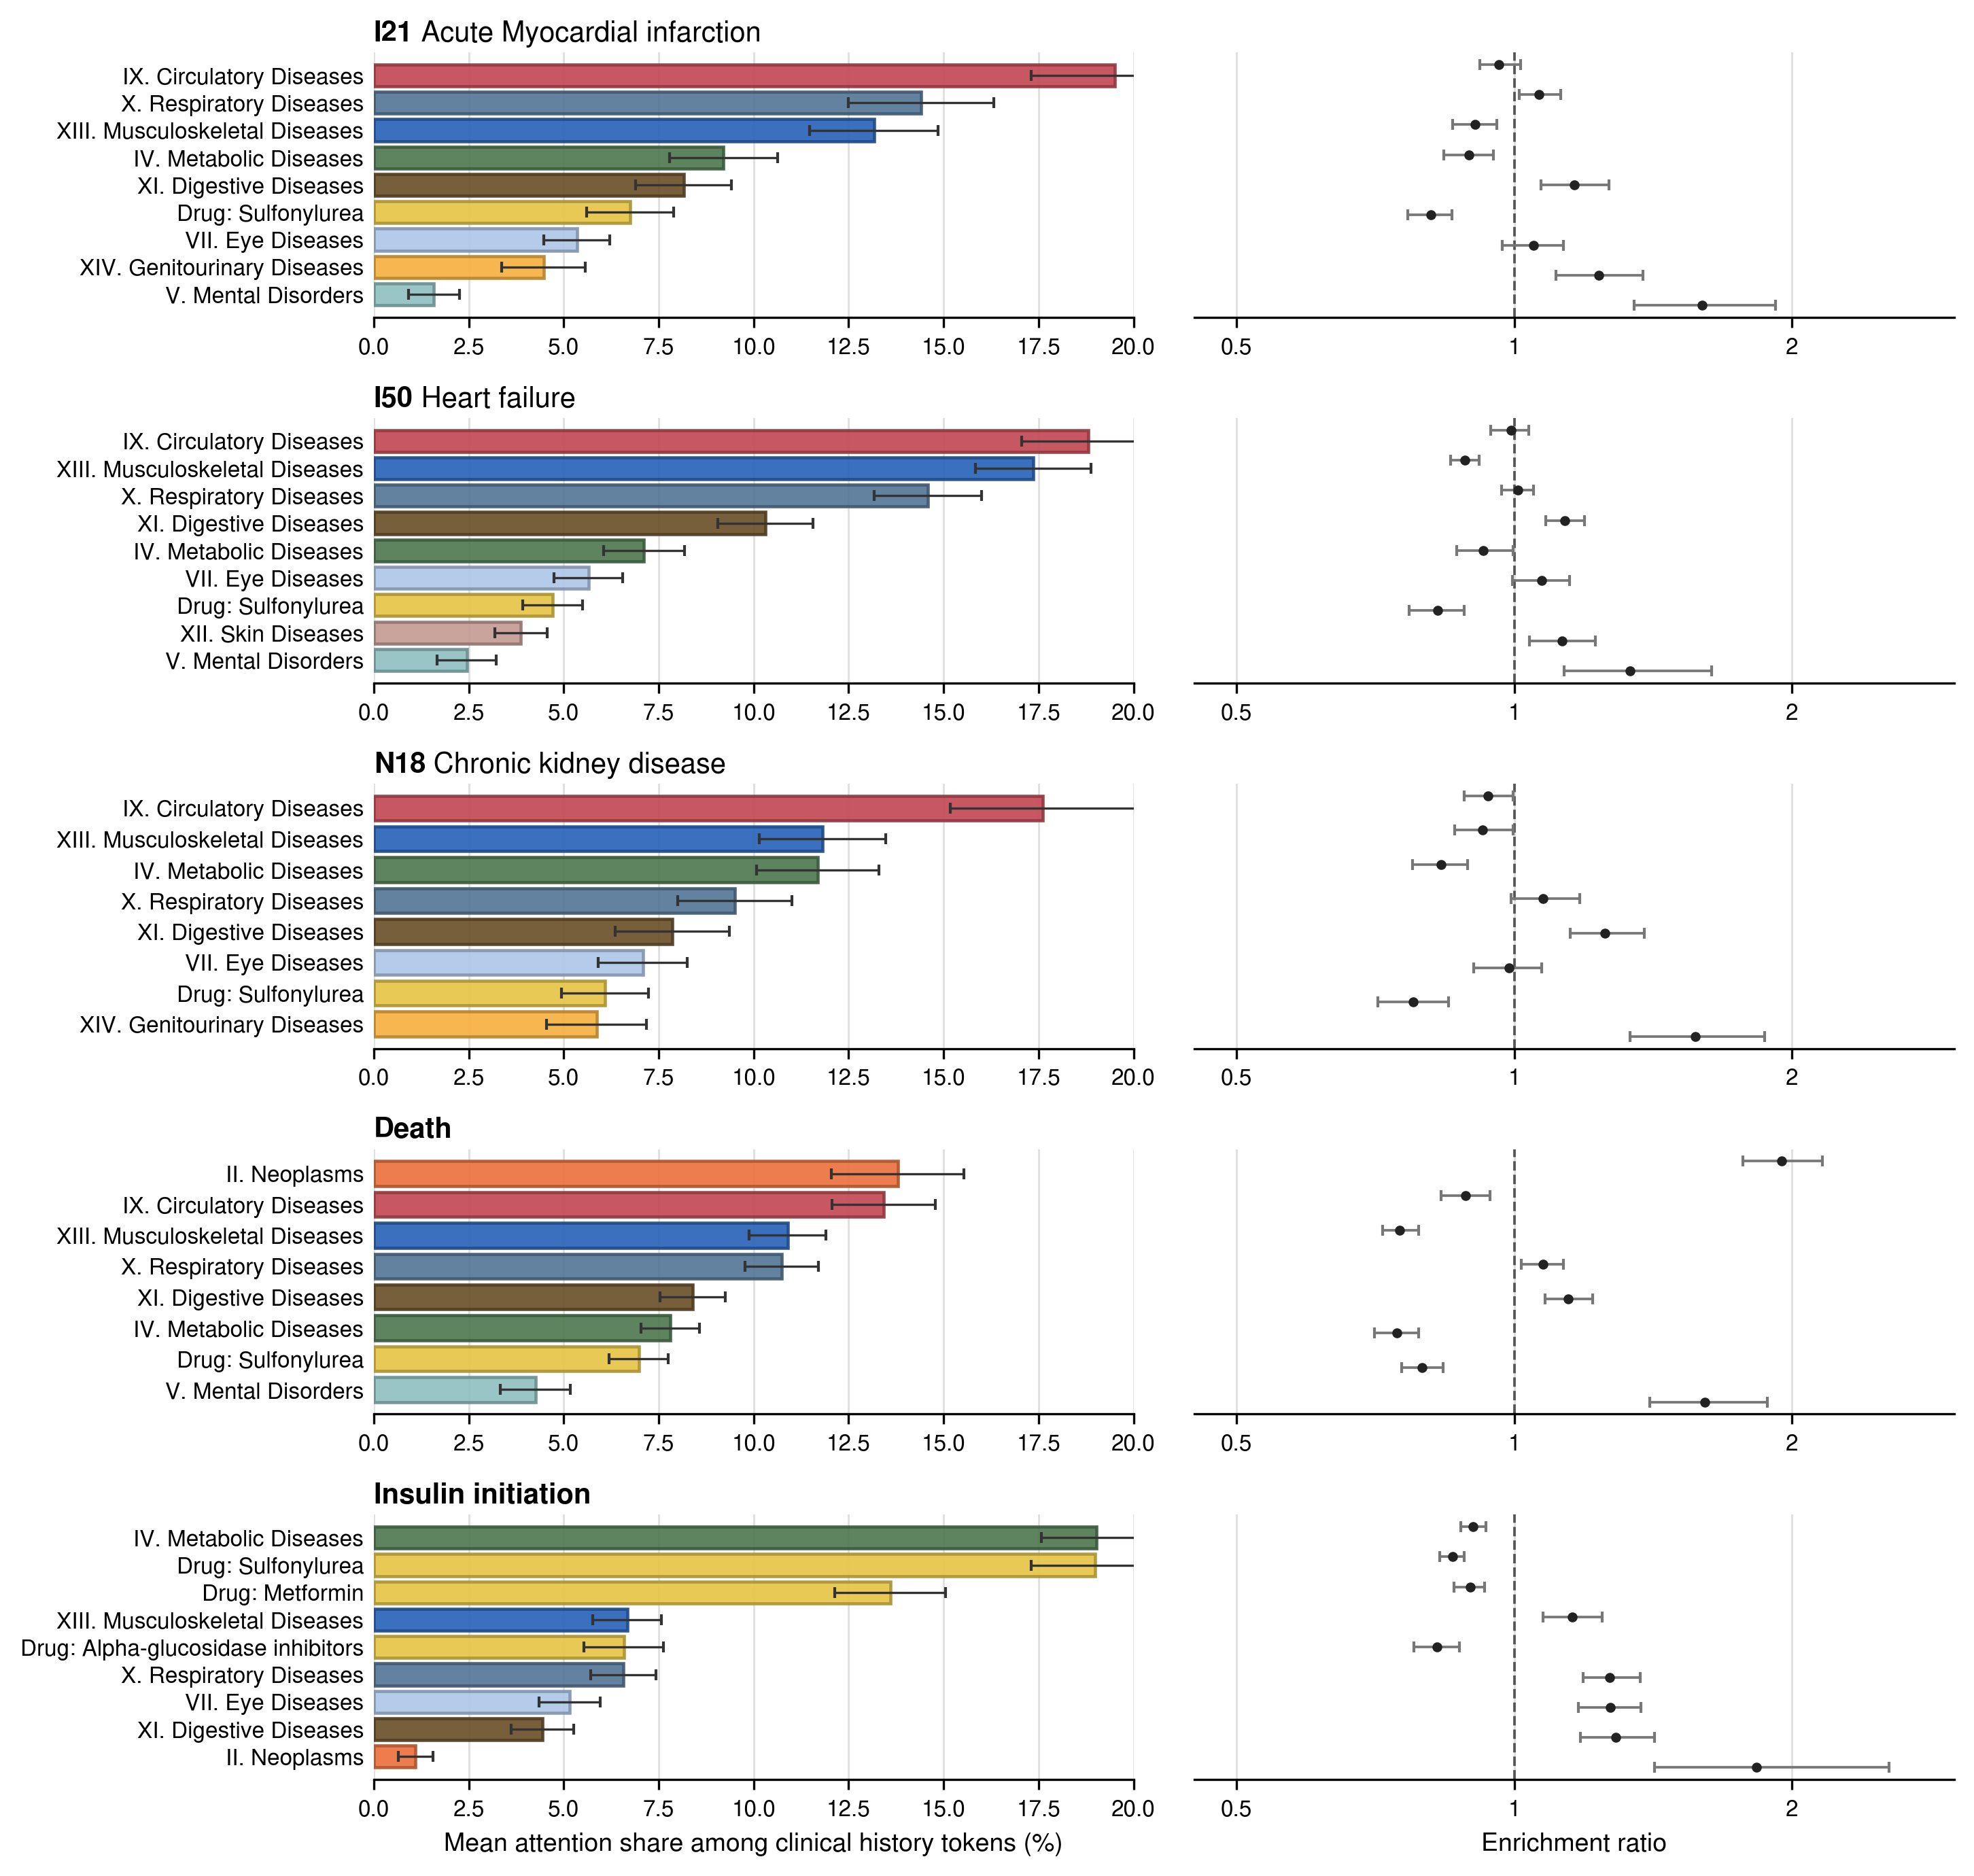

In [4]:
display(Image(filename=str(PNG_PATH)))

In [5]:
pd.read_csv(TOKEN_VALUES_PATH)

,target,token_id,display_label,patients_with_token,token_attention_share_included,token_count_share,token_enrichment_ratio
0,I21,508,I10 Essential primary hypertension,201,0.089903,0.115717,0.776920
1,I21,513,I20 Angina pectoris,118,0.049383,0.023181,2.130314
2,I21,518,I25 Chronic ischaemic heart disease,34,0.011357,0.004215,2.694464
3,I21,509,I11 Hypertensive heart disease,38,0.009511,0.007108,1.338020
4,I21,548,I63 Cerebral infarction,39,0.008601,0.009908,0.868140
5,I21,552,I67 Other cerebrovascular diseases,10,0.002442,0.001007,2.426469
6,I21,542,I50 Heart failure,14,0.002360,0.001698,1.389737
7,I21,541,I49 Other cardiac arrhythmias,12,0.002243,0.000912,2.458891


In [6]:
pd.read_csv(TOKEN_VALUES_PATH)[['display_label', 'patients_with_token', 'token_attention_share_included', 'token_count_share', 'token_enrichment_ratio']].sort_values('token_enrichment_ratio', ascending=False)

,display_label,patients_with_token,token_attention_share_included,token_count_share,token_enrichment_ratio
2,I25 Chronic ischaemic heart disease,34,0.011357,0.004215,2.694464
7,I49 Other cardiac arrhythmias,12,0.002243,0.000912,2.458891
5,I67 Other cerebrovascular diseases,10,0.002442,0.001007,2.426469
1,I20 Angina pectoris,118,0.049383,0.023181,2.130314
6,I50 Heart failure,14,0.002360,0.001698,1.389737
3,I11 Hypertensive heart disease,38,0.009511,0.007108,1.338020
4,I63 Cerebral infarction,39,0.008601,0.009908,0.868140
0,I10 Essential primary hypertension,201,0.089903,0.115717,0.776920


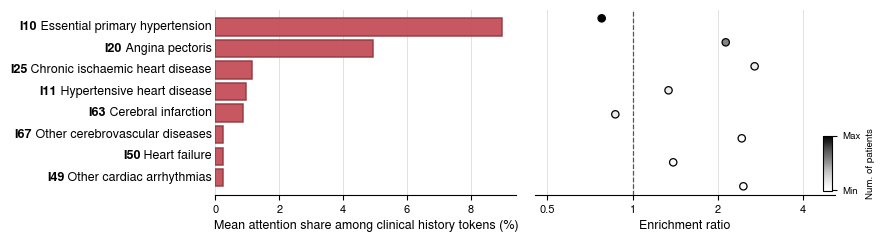

PNG: /home/hsh/hsh/GPT-Disease-Drug-Prediction/figure/out/attention_i21.png
PDF: /home/hsh/hsh/GPT-Disease-Drug-Prediction/figure/out/attention_i21.pdf


,target,token_id,display_label,patients_with_token,token_attention_share_included,token_count_share,token_enrichment_ratio
590,I21,508,I10 Essential primary hypertension,201,0.089903,0.115717,0.776920
593,I21,513,I20 Angina pectoris,118,0.049383,0.023181,2.130314
603,I21,518,I25 Chronic ischaemic heart disease,34,0.011357,0.004215,2.694464
610,I21,509,I11 Hypertensive heart disease,38,0.009511,0.007108,1.338020
614,I21,548,I63 Cerebral infarction,39,0.008601,0.009908,0.868140
671,I21,552,I67 Other cerebrovascular diseases,10,0.002442,0.001007,2.426469
674,I21,542,I50 Heart failure,14,0.002360,0.001698,1.389737
678,I21,541,I49 Other cardiac arrhythmias,12,0.002243,0.000912,2.458891


In [7]:
def generate_i21_figure() -> pd.DataFrame:
    """Standalone I21 circulatory token panel (bar = attention share, dot = enrichment).

    This is the panel that was removed from the main multi-target figure.
    """
    mpl.rcParams.update(
        {
            'font.family': FONT_FAMILY,
            'font.size': 9,
            'axes.titlesize': 10,
            'axes.labelsize': 9,
            'xtick.labelsize': 8,
            'ytick.labelsize': 9,
            'legend.fontsize': 8,
            'pdf.fonttype': 42,
            'ps.fonttype': 42,
        }
    )

    token = pd.read_csv(TOKEN_CSV)
    token_df = token[
        token['target'].eq('I21')
        & token['token_id'].isin(I21_CIRCULATORY_TOKEN_IDS)
    ].copy()
    token_df['display_label'] = token_df['token_id'].map(TOKEN_LABELS)
    token_df = token_df.sort_values('token_attention_share_included', ascending=True)

    y = np.arange(len(token_df))
    labels = [r.display_label for r in token_df.itertuples()]

    fig = plt.figure(figsize=(8.0, 2.4), constrained_layout=False)
    gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[1, 1], wspace=0.06)
    left_ax = fig.add_subplot(gs[0, 0])
    right_ax = fig.add_subplot(gs[0, 1])

    left_ax.barh(
        y,
        token_df['token_attention_share_included'] * 100,
        color=CIRCULATORY_COLOR,
        edgecolor=darken(CIRCULATORY_COLOR),
        linewidth=1.1,
        alpha=0.92,
    )
    set_split_yticklabels(left_ax, y, labels)
    left_ax.grid(axis='x', color='#D9D9D9', linewidth=0.7, alpha=0.8)
    left_ax.set_axisbelow(True)
    left_ax.spines[['top', 'right', 'left']].set_visible(False)
    left_ax.tick_params(axis='y', length=0)
    left_ax.set_xlabel('Mean attention share among clinical history tokens (%)')
    # left_ax.set_title('I21 circulatory tokens (token-level)', loc='left', fontweight='bold', pad=4)

    right_ax.axvline(1.0, color='#555555', linewidth=0.9, linestyle='--')
    # Colour dots by patient support: max -> black, min -> white (Greys colormap),
    # black edge for all points.
    support = token_df['patients_with_token'].to_numpy(dtype=float)
    smin, smax = support.min(), support.max()
    if smax > smin:
        norm = (support - smin) / (smax - smin)
    else:
        norm = np.ones_like(support)
    face_colors = plt.cm.Greys(norm)
    right_ax.scatter(
        token_df['token_enrichment_ratio'],
        y,
        s=28,
        facecolors=face_colors,
        edgecolors='black',
        linewidths=0.9,
        zorder=3,
    )
    sm = mpl.cm.ScalarMappable(cmap='Greys', norm=mpl.colors.Normalize(vmin=smin, vmax=smax))
    cax = right_ax.inset_axes([0.96, 0.02, 0.03, 0.3])
    cbar = fig.colorbar(sm, ax=right_ax, fraction=0.046, pad=0.04, cax=cax)
    cbar.set_label('Num. of patients', fontsize=7)
    cbar.ax.tick_params(labelsize=7)
    cbar.ax.set_yticks([12, 201])
    cbar.ax.set_yticklabels(['Min', 'Max'], fontsize=7)
    right_ax.set_yticks(y)
    right_ax.set_yticklabels([])
    right_ax.set_xscale('log')
    right_ax.set_xlim(0.45, 5.2)
    right_ax.set_xticks([0.5, 1, 2, 4])
    right_ax.set_xticklabels(['0.5', '1', '2', '4'])
    right_ax.xaxis.set_minor_formatter(mpl.ticker.NullFormatter())
    right_ax.tick_params(axis='x', which='minor', length=0)
    right_ax.grid(axis='x', which='major', color='#D9D9D9', linewidth=0.7, alpha=0.8)
    right_ax.set_axisbelow(True)
    right_ax.spines[['top', 'right', 'left']].set_visible(False)
    right_ax.tick_params(axis='y', length=0)
    right_ax.set_xlabel('Enrichment ratio')
    # right_ax.set_title('Attention / token frequency', loc='left', fontweight='bold')

    i21_prefix = 'attention_i21'
    for suffix in ['png', 'pdf']:
        fig.savefig(OUT_DIR / f'{i21_prefix}.{suffix}', dpi=300, bbox_inches='tight')
    display(fig)
    plt.close(fig)

    return token_df[
        [
            'target', 'token_id', 'display_label', 'patients_with_token',
            'token_attention_share_included', 'token_count_share', 'token_enrichment_ratio',
        ]
    ].sort_values('token_attention_share_included', ascending=False)


i21_token_values = generate_i21_figure()
print(f"PNG: {OUT_DIR / 'attention_i21.png'}")
print(f"PDF: {OUT_DIR / 'attention_i21.pdf'}")
i21_token_values